In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:85% !important;}
div.cell.code_cell.rendered{width:100%;}
div.input_prompt{padding:0px;}
div.CodeMirror {font-family:Consolas; font-size:20pt;}
div.output {font-size:12pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:20pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:5px;}
table.dataframe{font-size:20px;}
</style>
"""))

<font size="10" color="red">ch10.N차원 배열 다루기</font>
- N차원 배열객체 : 동일 자료형의 집합
- 2차원 배열은 행렬개념으로 이해
-[numpy] (https://numpy.org/)
-[numpy_API_Docs] (https://numpy.org/doc/stable/reference/index.html)
# 1절. 넘파이 패키지

In [3]:
import numpy as np
np.__version__ # tensorflow==2.0과 맞는 numpy 버젼

'1.23.5'

In [7]:
# np.arange(from,stop,by) : from부터 stop앞까지 by씩 증가하는 1차원 정수배열
a = np.arange(15)
print(a.shape) #15열자리 1차원 배열
a

(15,)


array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14])

## 1.1배열 속성

In [29]:
from numpy import arange
a = arange(15,
          #dtype =np.int8 
          ).reshape(3,5) # 3행 5열짜리로 변환
a

array([[ 0,  1,  2,  3,  4],
       [ 5,  6,  7,  8,  9],
       [10, 11, 12, 13, 14]])

In [30]:
type(a) #a변수의 타입

numpy.ndarray

In [31]:
a.dtype # a배열의 요소(item)들의 type

dtype('int32')

In [33]:
a.dtype.name

'int32'

In [34]:
a.itemsize # 한 요소(item)의 bytesize

4

In [35]:
a.ndim #축수(차원수)

2

In [36]:
a.size #배열 요소의 갯수

15

In [32]:
a.shape # 배열  구조(2차원 3행5열)

(3, 5)

In [37]:
print('shape 조정전 a:\n',a)
a.shape = (5,3)
print('shape 조정후 a:\n',a)

shape 조정전 a:
 [[ 0  1  2  3  4]
 [ 5  6  7  8  9]
 [10 11 12 13 14]]
shape 조정후 a:
 [[ 0  1  2]
 [ 3  4  5]
 [ 6  7  8]
 [ 9 10 11]
 [12 13 14]]


## 1.2 배열 타입 변경

In [40]:
# 배열 요소의 타입 변경(x)
a = np.arange(12).reshape(3, 4)
a

array([[ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11]])

In [41]:
a.size #요소갯수

12

In [42]:
a.dtype # 32bit씩 읽겠다.

dtype('int32')

In [43]:
a.itemsize

4

In [45]:
a.dtype = np.int64
a.dtype

dtype('int64')

In [46]:
a.itemsize # 요소의 byte 수

8

In [47]:
a

array([[ 4294967296, 12884901890],
       [21474836484, 30064771078],
       [38654705672, 47244640266]], dtype=int64)

In [48]:
a.size #요소수

6

In [59]:
# 배열 요소의 타입 변경(o)
a = arange(15).reshape(5,3)
a

array([[ 0,  1,  2],
       [ 3,  4,  5],
       [ 6,  7,  8],
       [ 9, 10, 11],
       [12, 13, 14]])

In [60]:
a.astype(np.int64) # 출력 o->a가 바뀌지않음. 출력x->a바뀜

array([[ 0,  1,  2],
       [ 3,  4,  5],
       [ 6,  7,  8],
       [ 9, 10, 11],
       [12, 13, 14]], dtype=int64)

In [63]:
a.dtype

dtype('int32')

In [55]:
a.ravel()# flaten된 배열을 return

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14])

In [56]:
a.flatten()

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14])

## 1.3 배열 저장
- pkl(객체, 배열, 머신러닝 모델 저장) vs npy(넘파이 전용포멧,io개선)

In [62]:
a

array([[ 0,  1,  2],
       [ 3,  4,  5],
       [ 6,  7,  8],
       [ 9, 10, 11],
       [12, 13, 14]])

In [66]:
%%time
import time
start = time.time()# 1970.1.1 부터 지금까지의초수
import pickle
with open('data/ch10.pkl','wb')as f:
    pickle.dump(a, f)
end =time.time()
print ('실행시간',(end-start))

실행시간 0.0
CPU times: total: 0 ns
Wall time: 0 ns


In [68]:
%%time
with open('data/ch10.pkl','rb')as f:
    loaded_a = pickle.load(f)

CPU times: total: 31.2 ms
Wall time: 3 ms


In [69]:
# a ==(파일저장)==>피클파일(269B)==(load)==>loaded+a
loaded_a


array([[ 0,  1,  2],
       [ 3,  4,  5],
       [ 6,  7,  8],
       [ 9, 10, 11],
       [12, 13, 14]])

In [70]:
%%time
np.save('data/ch11.npy',a) #넘파이 전용포맷, 빠르고 효율적 안전

CPU times: total: 0 ns
Wall time: 2.03 ms


In [71]:
%%time
loaded_a2 = np.load('data/ch11.npy')

CPU times: total: 15.6 ms
Wall time: 12.9 ms


In [72]:
# a==(저장)==>npy(248B)==(load)==> loaded_a2
loaded_a2

array([[ 0,  1,  2],
       [ 3,  4,  5],
       [ 6,  7,  8],
       [ 9, 10, 11],
       [12, 13, 14]])

# 2절. 넘파이 배열
- array()함수를 이용한 다른 파이선 데이터 구조(list,tup)를 배열 변환
- 특정값을 갖는 배열 생성함수 : arange, ones, zeros, full, empty...
- 랜덤값을 갖는 배열 생성함수 ....
- [넘파이함수들](https://numpy.org/doc/stable/reference/index.html)
## 2.1 array() 함수로 넘파일 배열 만들기
- array(object,dtype=np.type,copy=T/F)
- array(object,dtype='type',copy=T/F)

- type 예 : int16,int32,float16,float32,float64

In [73]:
a=np.array([2,14,6],
          # dtype=np.int16
          )#정수의 기본타입은 int32/실수의 기본 타입은 float64
a,a.dtype

(array([ 2, 14,  6]), dtype('int32'))

In [74]:
a[0],a[1],a[2]

(2, 14, 6)

In [75]:
for item in a:
    print(item,end='\t')

2	14	6	

In [78]:
b=np.array([[1.5,2.3],#동일 자료형의 집합으로 배열생성:정수>실수>문자
          [4,5]])     #실수 배열의 기본타입 : float64
b

array([[1.5, 2.3],
       [4. , 5. ]])

In [79]:
b.dtype

dtype('float64')

In [ ]:
l=[[1.5,2.3],[4,5]]


In [80]:
b[0,1] # 2차원[axis0=행,axis1=열] cf.1차원[axis0=열]

2.3

In [84]:
a=np.array([[1.5,2.3],[4,5]],
           #dtype="float32"
           dtype=np.float32
          ).reshape(1,4)
a

array([[1.5, 2.3, 4. , 5. ]], dtype=float32)

In [85]:
a.dtype

dtype('float32')

In [89]:
# a의 배열 구조변경
a.shape = (2,2)
a

array([[1.5, 2.3],
       [4. , 5. ]], dtype=float32)

In [91]:
# adml dtype(요소의 타입)변경
# a.dtype = np.float16
a=a.astype(np.float16)
a

array([[1.5, 2.3],
       [4. , 5. ]], dtype=float16)

In [104]:
l=[[1.5, 2.3],
   [4,5]]
for row in l:
    for item in row:
        print(item,end=' ')
    print()

1.5 2.3 
4 5 


In [105]:
for i,row in enumerate(l):
    for j,item in enumerate(row):
        #print(f"{i}행{j}열 : {a[i][j]}",end='\t') 
        print(f"{i}행{j}열 : {a[i,j]}",end='\t')#float16dms 소숫점이하가 불안정 
    print()

0행0열 : 1.5	0행1열 : 2.30078125	
1행0열 : 4.0	1행1열 : 5.0	


In [106]:
print(b[0,0]) #인덱싱
# print(b[0,2]) 없는 인덱싱은 에러

1.5


In [107]:
# 슬라이싱 from:stop:by : from부터 stop전까지 by씩 전진. 인덱싱은 음수
b[0:, 1:10] # 0~끝행,1열부터 열끝까지 슬라이싱(행과열 모두 슬라이싱 2차원 배열)

array([[2.3],
       [5. ]])

In [108]:
b[0,1:3] #0행 1열부터 3열까지 슬라이싱(열만 슬라이싱 1차원 배열)

array([2.3])

In [120]:
b=np.array([[1,2,3],
            [6,7,8]])
b[:,-1:],b[:,-1]
# 모든 행의 마지막 열만 추출

(array([[3],
        [8]]),
 array([3, 8]))

In [ ]:
# 모든 행의 마지막 열을 제외한 부분 추출

In [130]:
b[:,:-1]

array([[1, 2],
       [6, 7]])

In [131]:
# 스칼라 변수
a=10 #원본
b=a #복제본
print("a={},b{},a주소{},b주소{}".format(a,b,id(a),id(b)))
b=-1
print("a={},b{},a주소{},b주소{}".format(a,b,id(a),id(b)))

a=10,b10,a주소2018177581584,b주소2018177581584
a=10,b-1,a주소2018177581584,b주소2018177581232


In [142]:
# numpy 배열
c=np.array([[1,2],[3,4]],dtype=np.int8)# 원본
d=np.array(c,copy=True) #d = c.copy()와 동일 #깊은 복사 
print("c=",c,sep="\n")
print("d=",d,sep="\n")
print('두 변수의 주소:',id(c),id(d))

d[0, 0]=9
print("c=",c,sep="\n")
print("d=",d,sep="\n")
print('두 변수의 주소:',id(c),id(d))

c=
[[1 2]
 [3 4]]
d=
[[1 2]
 [3 4]]
두 변수의 주소: 2018318421712 2018318420944
c=
[[1 2]
 [3 4]]
d=
[[9 2]
 [3 4]]
두 변수의 주소: 2018318421712 2018318420944


In [143]:
# numpy 배열
c=np.array([[1,2],[3,4]],dtype=np.int8)# 원본
d=np.array(c,copy=False, dtype=np.int32) 
print("c=",c,sep="\n")
print("d=",d,sep="\n")
print('두 변수의 주소:',id(c),id(d))
d[0, 0]=9
print("c=",c,sep="\n")
print("d=",d,sep="\n")
print('두 변수의 주소:',id(c),id(d))

c=
[[1 2]
 [3 4]]
d=
[[1 2]
 [3 4]]
두 변수의 주소: 2018318421904 2018318421712
c=
[[1 2]
 [3 4]]
d=
[[9 2]
 [3 4]]
두 변수의 주소: 2018318421904 2018318421712


## 2.2 기본값이 있는 배열 만들기
- np.zeros(tup[,dtype]) : 요소들이 다 0.0
- np.ones(tup[,dtype]) : 요소들이 다 1.0
- np.pull(tup[,dtype]) : 요소들이 다 두번째 매개변수인 기본값
- np.empty(tup) : 초기 내용은 임의의 값인 배열(메모리 상태에 따라 달라짐)

※ 위의 함수를 이용해서 생성된 배열은 기본 dtype이 float64,type속성을 따로 지정할 수 있음

In [208]:
np.zeros((3,5)) #3행 5열짜리 차원 float64 배열(요소들은다 0)
np.zeros((5,))  #5열짜리 1차원 float64배열(요소들은 다 0)
np.zeros(5) # 5열짜리 1차원float64 배열(요소들은다 0)

array([0., 0., 0., 0., 0.])

In [211]:
x=np.zeros((2, 5),dtype=np.bool8)
print(x)
print(x.dtype)
print(x.itemsize)

[[False False False False False]
 [False False False False False]]
bool
1


In [212]:
np.ones((3,5)) #3행 5열짜리 차원 float64 배열(요소들은다 1)
np.ones((5,))  #5열짜리 1차원 float64배열(요소들은 다 1)
np.ones(5) # 5열짜리 1차원float64 배열(요소들은다 1)

array([1., 1., 1., 1., 1.])

In [213]:
x=np.ones((2, 5),dtype=np.bool8)
print(x)
print(x.dtype)
print(x.itemsize)

[[ True  True  True  True  True]
 [ True  True  True  True  True]]
bool
1


In [216]:
x=np.full((2,5),255)
print(x)
print(x.dtype)

[[255 255 255 255 255]
 [255 255 255 255 255]]
int32


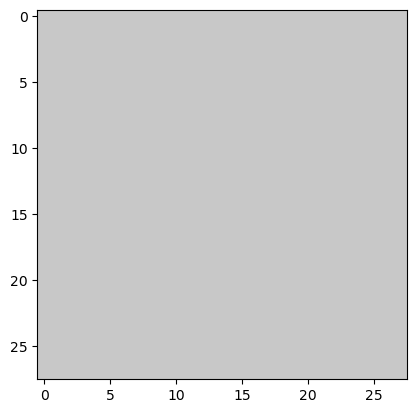

In [221]:
import matplotlib.pyplot as plt
img = np.full((28,28),255,dtype=np.uint8) #=하얀색
img = np.full((28,28),200,dtype=np.uint8) #=회색
#plt.figure(figsize=(1,1))
plt.imshow(img, cmap='gray', vmin=0,vmax=255)
# plt.axis('off')
plt.show()

In [223]:
import numpy as np
np.empty((3,2))

array([[0.37472222, 0.33722222],
       [0.37472222, 4.03322222],
       [4.07072222, 0.33722222]])

## 2.3 랜덤값을 갖는 배열 만들기
- np.random.random(tup) : 0부터 1미만의 균등 분포를 갖는 tup사이즈 랜덤값
- np.random.uniform(low=0, high=1.0, size=tup) : low부터 high미만까지 균등분포를 갖는 랜덤값
- np.random.normal(loc=0.0,scale=1.0,size=tup) : 평균loc,표준편차scale을 갖는 정규분포 랜덤값
- np.random.rand(n) : 균등분포의 1차원 난수 배열 발생(난수가 n개)
- np.random.randa(n) : 표준 정규 분포(평균이 0이고 표준편차가1인 정규분포)의 1차원 난수배열발생(난수n개)

- np.rendom.randint(n) 0부터 n미만의 정수 난수 1개 발생==random.randint(0,n-1)
- np.random.randint(from,to) : from부터 새 미만의 정수 난수 1개 발생
                    ==random.randint(from,to)

In [224]:
np.random.random((2,3))

array([[0.81177852, 0.48090204, 0.74776089],
       [0.46574553, 0.91653708, 0.98729967]])

In [226]:
np.random.rand((2))

array([0.90649701, 0.67603113])

In [227]:
np.random.rand(100000)

array([0.56960574, 0.26469163, 0.95605281, ..., 0.69926406, 0.64897171,
       0.39912261])

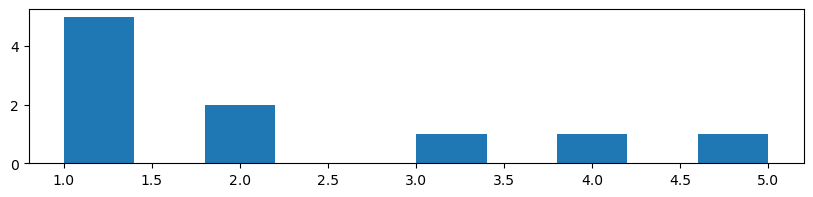

In [242]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,2)) # 그래프 사이즈 조절
x= [1,2,3,1,2,1,1,4,5,1]
plt.hist(x,bins=10)
plt.show()

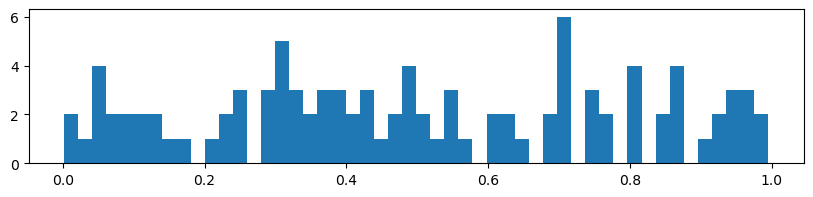

In [244]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,2)) # 그래프 사이즈 조절
# x= np.random.random(100)
x=np.random.rand(100)
plt.hist(x,bins=50)
plt.show()

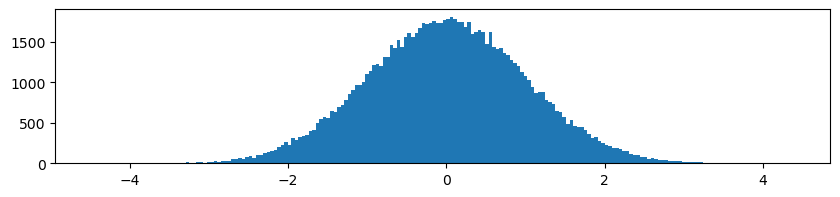

In [254]:
plt.figure(figsize=(10,2)) # 그래프 사이즈 조절
x=np.random.normal(50,10, 1000000) #정규분포
x=np.random.normal(0,1, 1000000) #표준정규분포
x=np.random.randn(100000)
plt.hist(x,bins=200)
plt.show()

# 4절. 복사와 뷰
## 4.1 할당

In [146]:
# 스칼라 변수
a=10
b=a
print('a와 b주소 : ',id(a),id(b))
b=99
print('수정 후 a와 b주소:',id(a),id(b))
print('수정 후 a와 b데이타:' ,a, b)

a와 b주소 :  2018177581584 2018177581584
수정 후 a와 b주소: 2018177581584 2018177584432
수정 후 a와 b데이타: 10 99


In [147]:
# 배열
a=np.arange(12)
a

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11])

In [149]:
b=a
# b=np.array(a,copy=False)와 같음
a.shape,type(a),a.ndim,id(a)

((12,), numpy.ndarray, 1, 2018318418640)

In [150]:
a is b

True

In [151]:
a==b

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True])

In [152]:
np.all(a==b) # np.all()array배열안의 모든 값이 True인지 여부

True

In [153]:
b.shape = (3,4)

In [154]:
b.shape, type(b),b.ndim,id(b)

((3, 4), numpy.ndarray, 2, 2018318418640)

In [155]:
a is b

True

In [156]:
a.shape

(3, 4)

In [157]:
a

array([[ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11]])

## 4.2 뷰(view): 얕은 복사

In [159]:
a= np.arange(12).reshape(3,4)
a

array([[ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11]])

In [160]:
c = a.view() #얕은 복사
c

array([[ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11]])

In [161]:
id(a),id(c)

(2018318477200, 2018328744016)

In [164]:
a==c

array([[ True,  True,  True,  True],
       [ True,  True,  True,  True],
       [ True,  True,  True,  True]])

In [165]:
np.all(a==c)

True

In [167]:
a is c

False

In [171]:
c.shape = (2,6)
c

array([[ 0,  1,  2,  3,  4,  5],
       [ 6,  7,  8,  9, 10, 11]])

In [172]:
a

array([[ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11]])

In [175]:
# 배열 복사본 c의 특정 요소만 변경
c[1,::2]=-99
c

array([[  0,   1,   2,   3,   4,   5],
       [-99,   7, -99,   9, -99,  11]])

In [176]:
a

array([[  0,   1,   2,   3],
       [  4,   5, -99,   7],
       [-99,   9, -99,  11]])

In [197]:
# 슬라이싱이 될때 뷰가 반환됨(shape과 dtype변경외는 원본도 변경)
a=np.array([[99, 88, 77, 85],
          [99, 71, 75, 70],
          [99, 95, 90, 95],])
a

array([[99, 88, 77, 85],
       [99, 71, 75, 70],
       [99, 95, 90, 95]])

In [194]:
X = a[:,:-1].copy()
X

array([[99, 88, 77],
       [99, 71, 75],
       [99, 95, 90]])

In [195]:
X[0:2, -1] =1
X[-1, -1] = -1
X

array([[99, 88,  1],
       [99, 71,  1],
       [99, 95, -1]])

In [196]:
a

array([[99, 88, 77, 85],
       [99, 71, 75, 70],
       [99, 95, 90, 95]])

## 4.3 깊은 복사

In [198]:
# 슬라이싱이 될때 뷰가 반환됨(shape과 dtype변경외는 원본도 변경)
a=np.array([[99, 88, 77, 85],
          [99, 71, 75, 70],
          [99, 95, 90, 95],])
a

array([[99, 88, 77, 85],
       [99, 71, 75, 70],
       [99, 95, 90, 95]])

In [ ]:
#X=a[:,:-1] #얕은 복사(view생성)
X=a[:,:-1].copy() #깊은 복사
#X= np.array(a[:,:-1],copy=True) # 깊은복사

In [199]:
X[:,0:2] = 1
X[-1,-1] =-1
X

array([[ 1,  1,  1],
       [ 1,  1,  1],
       [ 1,  1, -1]])

In [200]:
a

array([[99, 88, 77, 85],
       [99, 71, 75, 70],
       [99, 95, 90, 95]])